### 이상치

- 값이 이상한 데이터를 의미
    - 결측치
    - 범위에서 벗어나는 데이터
    - 값이 크게 벗어나는 데이터

- 분석 모델의 성능을 저하시키거나, 결과에 악영향을 미치는 경우가 발생
- 이상치 데이터 발견시 즉시 처리
    - 특정한 값으로 대체
        - 데이터의 양은 보존
        - 데이터가 신뢰도 하락 가능성이 존재
        - 분석의 성능이 떨어지는 경우 발생
        - 데이터 분포의 과밀화가 종종 발생
    - 데이터를 제거
        - 소량의 데이터에서 제거한다면 학습 데이터가 부족해지는 경우가 발생
        - 이상치 데이터가 너무 많은 경우 많은 양의 데이터가 제거
- 결측치를 확인하는 방법
    - isna() 함수를 이용하여 결측치의 유무를 판단
    - sum() 함수를 이용하여 결측치의 개수를 확인
    - info() 함수를 이용하여 non-null count를 확인
- 특정 범위를 벗어나는 데이터를 확인하는 방법
    - unique() 함수를 이용하여 특정 필드의 유일 데이터를 확인
    - value_counts() 함수를 이용하여 특정 필드 데이터들의 빈도수를 확인
    - isin() 함수를 이용하여 특정 값들에 포함되어있는가를 확인하고 부정연산자를 이용하여 데이터를 확인
- 극단치(값이 크게 벗어나는 데이터)를 확인
    - IQR 방식
        - boxplot() 수염의 경계 (상단: Q3+1.5IQR, 하단: Q1-1.5IQR)
        - Q3와 Q1를 이용하여 극단치의 범위를 지정 (IQR = Q3-Q1)
        - 상단의 경계보다 크거나 하단의 경계보다 작은 경우 극단치로 판단

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine

In [3]:
wine_data = load_wine()
wine_data.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names'])

- scikit-learn 샘플 데이터의 key
    - data
        - 독립변수(데이터)
    - target
        - 종속변수(데이터)
    - frame
        - 독립변수와 종속변수 데이터를 모두 포함하여 데이터프레임으로 제공
        - 데이터가 존재하지 않는 경우도 있음
    - target_name
        - 종속 변수들의 의미
    - DESCR
        - 데이터의 정보를 확인
    - feature_names
        - feature(column)의 이름을 확인

In [4]:
# frame을 제공하는가?
wine_data['frame']

In [ ]:
wine = pd.DataFrame(
    data = wine_data['data'],
    columns = wine_data['feature_names']
)

wine

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0


In [6]:
# 종속변수도 데이터프레임에 추가
wine['class'] = wine_data['target']

In [7]:
wine

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,class
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0,2
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0,2
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0,2
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0,2


In [9]:
# target 데이터의 의미는 target_names
wine_data['target_names']

array(['class_0', 'class_1', 'class_2'], dtype='<U7')

In [10]:
wine.info()

<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  class           

In [11]:
# class 데이터에서 0, 1, 2를 제외한 데이터가 존재하는가?
# case1: unique()

wine['class'].unique()

array([0, 1, 2])

In [12]:
# case2: value_counts()

wine['class'].value_counts()

class
1    71
0    59
2    48
Name: count, dtype: int64

In [ ]:
# case3: isin() 함수를 활용, 결측치가 있는지 먼저 확인하고 보는 것이 깔끔

wine['class'].isin([0, 1, 2]).sum()

np.int64(178)

In [15]:
flag = wine['class'].isin([0, 1, 2])
wine.loc[~flag,]

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,class


In [16]:
# 극단치 데이터를 확인
# describe() 함수
wine.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,class
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


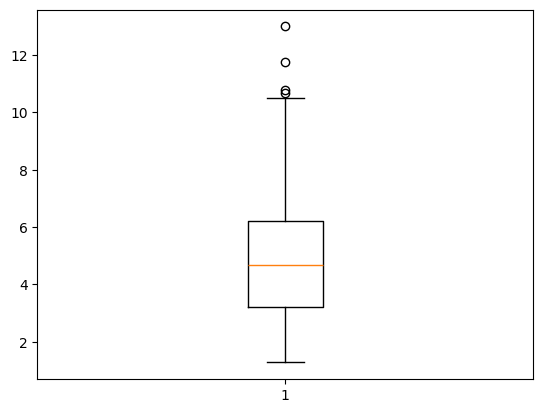

In [19]:
# boxplot() 함수를 이용하여 극단치 경계에서 벗어나는 데이터의 존재유무를 확인
# 특정 column(color_intensity)를 이용하여 확인

plt.boxplot(wine['color_intensity'])
plt.show()

In [21]:
# 3사분위수 출력 → describe() 함수를 사용해서 추출 가능
wine['color_intensity'].describe()['75%']

np.float64(6.2)

In [26]:
# numpy 라이브러리를 사용해서 사분위수 출력 가능
# 첫번째 인자는 데이터들, 두번째 인자는 몇퍼센트의 값들을 선택할 것인가

q_1, q_3 = np.percentile(wine['color_intensity'], [25, 75])
print(q_1)
print(q_3)

3.2199999999999998
6.2


In [28]:
# IQR 계산
iqr = q_3 - q_1

# 상단 경계 계산
iqr_top = q_3 + 1.5*iqr

# 하단 경계 계산
iqr_bottom = q_1 - 1.5*iqr

print(iqr, iqr_top, iqr_bottom)

2.9800000000000004 10.670000000000002 -1.2500000000000009


In [34]:
upper_flag = wine['color_intensity'] > iqr_top
lower_flag = wine['color_intensity'] < iqr_bottom

In [35]:
wine.loc[upper_flag | lower_flag, ]

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,class
151,12.79,2.67,2.48,22.0,112.0,1.48,1.36,0.24,1.26,10.80,0.48,1.47,480.0,2
158,14.34,1.68,2.70,25.0,98.0,2.80,1.31,0.53,2.70,13.00,0.57,1.96,660.0,2
159,13.48,1.67,2.64,22.5,89.0,2.60,1.10,0.52,2.29,11.75,0.57,1.78,620.0,2
166,13.45,3.70,2.60,23.0,111.0,1.70,0.92,0.43,1.46,10.68,0.85,1.56,695.0,2


In [56]:
df = wine.copy()

In [ ]:
# 극단치 제거
# 1) drop // 2) 극단치 경계식에 부정연산자를 추가하여 필터링 // 3) 극단치의 데이터를 결측치로 대체한뒤 제거

out_idx = df.loc[upper_flag | lower_flag, ].index
df.drop(out_idx, axis=0)

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,class
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0,2
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0,2
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0,2
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0,2


In [61]:
df.loc[ ~(upper_flag | lower_flag), ]

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,class
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0,2
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0,2
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0,2
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0,2


In [63]:
df.loc[(upper_flag|lower_flag), 'color_intensity'] = np.nan

In [64]:
df.dropna()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,class
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0,2
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0,2
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0,2
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0,2


In [65]:
# 극단치 대체
# 상단의 경계에서 벗어난 데이터는 상단의 경계 값으로 채워주고
# 하단의 경계에서 벗어난 데이터는 하단의 경계 값으로 채워준다.
df2 = wine.copy()

In [66]:
df2.loc[upper_flag, 'color_intensity'] = iqr_top

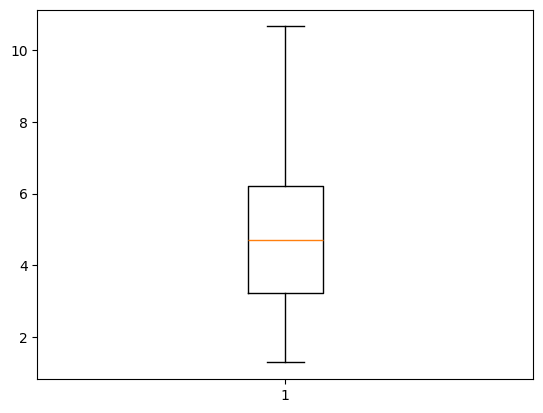

In [68]:
plt.boxplot(df2['color_intensity'])
plt.show()

- 극단치의 데이터를 확인하고 대체하거나 제거하는 함수를 생성
    - 원본의 데이터는 그대로 유지한 상태에서 데이터를 제공하는 함수
    - 매개변수 4개
        - data → 필수 항목 → 데이터프레임
        - col → 필수 항목 → 극단치 데이터를 확인하려는 컬럼의 이름
        - n → 기본값 1.5 지정 → 극단치의 경계 범위를 지정
        - drop → 기본값 False → 결측치 데이터를 제거할 것인가, 대체할 것인가
    - 지정이 된 컬럼을 선택하여 1, 3 사분위수를 추출
    - IQR 계산
    - n의 값을 이용하여 상/하단의 경계 생성
    - 상/하단의 경계에서 벗어나는 데이터의 개수를 출력
    - drop의 값에 따라 제거할 것인지 대체할 것인지 지정
    - 결과물인 데이터 프레임을 되돌려준다.

In [77]:
def outlier_iqr(data, col, n = 1.5, drop = False):
    # 원본의 데이터를 그대로 유지하기 위해서 복사
    df = data.copy()
    # 입력으로 받은 데이터프레임 안에 col의 값이 column으로 존재하는가?
    # if col in df.columns:
    # 우선 실행하고 에러가 발생하면 예외 처리
    try:
        # 1, 3 사분위수 계산
        q_1, q_3 = np.percentile(df[col], [25, 75])
        iqr = q_3 - q_1

        # 상단의 경계, 하단의 경계 값 계산
        upper_whis = q_3 + (n * iqr)
        lower_whis = q_1 - (n * iqr)

        # 경계값들을 출력
        print(f'''
              지정된 컬럼의 이름: {col},
              상단 경계: {upper_whis},
              하단 경계 {lower_whis}''')

        # 상단의 경계를 벗어나는 데이터의 개수 확인
        upper_flag = df[col] > upper_whis
        lower_flag = df[col] < lower_whis
        upper_n = len( df.loc[upper_flag, ] )
        lower_n = len( df.loc[lower_flag, ] )
        print(f'상단 경계를 벗어나는 데이터의 개수: {upper_n}, 하단 경계를 벗어나는 데이터의 개수: {lower_n}')
        whis_df = df.loc[upper_flag|lower_flag, ]

        if drop:
            # drop = True: 극단치들을 제거한다
            df = df.loc[ ~(upper_flag | lower_flag), ]
        else:
            # drop = False: 극단치들을 대체한다
            df.loc[upper_flag, col] = upper_whis
            df.loc[lower_flag, col] = lower_whis
        
        # 결과물, 극단치의 경계에서 벗어난 데이터들을 되돌려준다.
        return df, whis_df

    except Exception as e:
        print(f'Error: {e}')

In [84]:
df3, whis_df = outlier_iqr(wine, 'color_intensity')


              지정된 컬럼의 이름: color_intensity,
              상단 경계: 10.670000000000002,
              하단 경계 -1.2500000000000009
상단 경계를 벗어나는 데이터의 개수: 4, 하단 경계를 벗어나는 데이터의 개수: 0


In [85]:
df3

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,class
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0,2
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0,2
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0,2
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0,2


In [86]:
# 수정작업 1차: 2번째 매개변수 column의 값을 가변 인자로 변경 (col → cols)

def outlier_iqr2(data, *cols, n = 1.5, drop = False):
    df = data.copy()
    # 수정 1차: 반복문 추가
    # 경계에서 벗어난 데이터프레임들을 dict 형태로 되돌려준다. {col: DataFrame, col2: DataFrame}

    whis_dict = {}

    for col in cols:
        try:
            q_1, q_3 = np.percentile(df[col], [25, 75])
            iqr = q_3 - q_1

            upper_whis = q_3 + (n * iqr)
            lower_whis = q_1 - (n * iqr)

            print(f'''
                지정된 컬럼의 이름: {col},
                상단 경계: {upper_whis},
                하단 경계 {lower_whis}''')

            upper_flag = df[col] > upper_whis
            lower_flag = df[col] < lower_whis
            upper_n = len( df.loc[upper_flag, ] )
            lower_n = len( df.loc[lower_flag, ] )
            print(f'상단 경계를 벗어나는 데이터의 개수: {upper_n}, 하단 경계를 벗어나는 데이터의 개수: {lower_n}')
            whis_df = df.loc[upper_flag|lower_flag, ]
            # whis_df를 whis_dict에 추가
            whis_dict[col] = whis_df

            if drop:
                df = df.loc[ ~(upper_flag | lower_flag), ]
            else:
                df.loc[upper_flag, col] = upper_whis
                df.loc[lower_flag, col] = lower_whis

        except Exception as e:
            print(f'Error: {e}')
    
    return df, whis_dict

In [87]:
df4, whis_df = outlier_iqr2(wine, 'color_intensity', drop=False)


                지정된 컬럼의 이름: color_intensity,
                상단 경계: 10.670000000000002,
                하단 경계 -1.2500000000000009
상단 경계를 벗어나는 데이터의 개수: 4, 하단 경계를 벗어나는 데이터의 개수: 0


In [88]:
df4

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,class
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0,2
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0,2
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0,2
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0,2


In [89]:
whis_df

{'color_intensity':      alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
 151    12.79        2.67  2.48               22.0      112.0           1.48   
 158    14.34        1.68  2.70               25.0       98.0           2.80   
 159    13.48        1.67  2.64               22.5       89.0           2.60   
 166    13.45        3.70  2.60               23.0      111.0           1.70   
 
      flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
 151        1.36                  0.24             1.26            10.80  0.48   
 158        1.31                  0.53             2.70            13.00  0.57   
 159        1.10                  0.52             2.29            11.75  0.57   
 166        0.92                  0.43             1.46            10.68  0.85   
 
      od280/od315_of_diluted_wines  proline  class  
 151                          1.47    480.0      2  
 158                          1.96    660.0      2  
 159    

In [90]:
whis_df['color_intensity']

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,class
151,12.79,2.67,2.48,22.0,112.0,1.48,1.36,0.24,1.26,10.80,0.48,1.47,480.0,2
158,14.34,1.68,2.70,25.0,98.0,2.80,1.31,0.53,2.70,13.00,0.57,1.96,660.0,2
159,13.48,1.67,2.64,22.5,89.0,2.60,1.10,0.52,2.29,11.75,0.57,1.78,620.0,2
166,13.45,3.70,2.60,23.0,111.0,1.70,0.92,0.43,1.46,10.68,0.85,1.56,695.0,2


In [91]:
df5, whis_df = outlier_iqr2(wine, 'color_intensity', 'ash', drop=True)


                지정된 컬럼의 이름: color_intensity,
                상단 경계: 10.670000000000002,
                하단 경계 -1.2500000000000009
상단 경계를 벗어나는 데이터의 개수: 4, 하단 경계를 벗어나는 데이터의 개수: 0

                지정된 컬럼의 이름: ash,
                상단 경계: 3.035,
                하단 경계 1.7149999999999999
상단 경계를 벗어나는 데이터의 개수: 2, 하단 경계를 벗어나는 데이터의 개수: 4


In [92]:
df5

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,class
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0,2
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0,2
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0,2
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0,2


In [93]:
whis_df

{'color_intensity':      alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
 151    12.79        2.67  2.48               22.0      112.0           1.48   
 158    14.34        1.68  2.70               25.0       98.0           2.80   
 159    13.48        1.67  2.64               22.5       89.0           2.60   
 166    13.45        3.70  2.60               23.0      111.0           1.70   
 
      flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
 151        1.36                  0.24             1.26            10.80  0.48   
 158        1.31                  0.53             2.70            13.00  0.57   
 159        1.10                  0.52             2.29            11.75  0.57   
 166        0.92                  0.43             1.46            10.68  0.85   
 
      od280/od315_of_diluted_wines  proline  class  
 151                          1.47    480.0      2  
 158                          1.96    660.0      2  
 159    

In [94]:
whis_df['color_intensity']

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,class
151,12.79,2.67,2.48,22.0,112.0,1.48,1.36,0.24,1.26,10.80,0.48,1.47,480.0,2
158,14.34,1.68,2.70,25.0,98.0,2.80,1.31,0.53,2.70,13.00,0.57,1.96,660.0,2
159,13.48,1.67,2.64,22.5,89.0,2.60,1.10,0.52,2.29,11.75,0.57,1.78,620.0,2
166,13.45,3.70,2.60,23.0,111.0,1.70,0.92,0.43,1.46,10.68,0.85,1.56,695.0,2


In [95]:
whis_df['ash']

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,class
25,13.05,2.05,3.22,25.0,124.0,2.63,2.68,0.47,1.92,3.58,1.13,3.20,830.0,0
59,12.37,0.94,1.36,10.6,88.0,1.98,0.57,0.28,0.42,1.95,1.05,1.82,520.0,1
66,13.11,1.01,1.70,15.0,78.0,2.98,3.18,0.26,2.28,5.30,1.12,3.18,502.0,1
76,13.03,0.90,1.71,16.0,86.0,1.95,2.03,0.24,1.46,4.60,1.19,2.48,392.0,1
100,12.08,2.08,1.70,17.5,97.0,2.23,2.17,0.26,1.40,3.30,1.27,2.96,710.0,1
121,11.56,2.05,3.23,28.5,119.0,3.18,5.08,0.47,1.87,6.00,0.93,3.69,465.0,1


In [101]:
df6, whis_dict = outlier_iqr2(wine, *wine.columns, drop=True)


                지정된 컬럼의 이름: alcohol,
                상단 경계: 15.650000000000002,
                하단 경계 10.389999999999997
상단 경계를 벗어나는 데이터의 개수: 0, 하단 경계를 벗어나는 데이터의 개수: 0

                지정된 컬럼의 이름: malic_acid,
                상단 경계: 5.3025,
                하단 경계 -0.6174999999999997
상단 경계를 벗어나는 데이터의 개수: 3, 하단 경계를 벗어나는 데이터의 개수: 0

                지정된 컬럼의 이름: ash,
                상단 경계: 3.0724999999999993,
                하단 경계 1.6925000000000003
상단 경계를 벗어나는 데이터의 개수: 2, 하단 경계를 벗어나는 데이터의 개수: 1

                지정된 컬럼의 이름: alcalinity_of_ash,
                상단 경계: 27.987499999999997,
                하단 경계 10.687500000000002
상단 경계를 벗어나는 데이터의 개수: 2, 하단 경계를 벗어나는 데이터의 개수: 0

                지정된 컬럼의 이름: magnesium,
                상단 경계: 135.5,
                하단 경계 59.5
상단 경계를 벗어나는 데이터의 개수: 3, 하단 경계를 벗어나는 데이터의 개수: 0

                지정된 컬럼의 이름: total_phenols,
                상단 경계: 4.435,
                하단 경계 0.07500000000000018
상단 경계를 벗어나는 데이터의 개수: 0, 하단 경계를 벗어나는 데이터의 개수: 0

                지정

In [102]:
df6

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,class
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
172,14.16,2.51,2.48,20.0,91.0,1.68,0.70,0.44,1.24,9.70,0.62,1.71,660.0,2
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0,2
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0,2
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0,2


### 범주형 데이터의 변환

- 학습 모델이 대부분 수학적인 연산으로 모델을 생성하기 때문에, 범주형 변수는 직접적으로 사용하기 어렵다.
    - 때문에 특별 가공 처리를 한다.
- 더미 변수 생성
    - 범주형 데이터를 각각의 column으로 생성
    - 0과 1로 데이터를 대입하여 포함 여부를 생성

In [103]:
# class column의 값들을 범주형으로 변경
wine_data['target_names']

array(['class_0', 'class_1', 'class_2'], dtype='<U7')

In [105]:
wine['class'] = wine['class'].map(
    lambda x: wine_data['target_names'][x]
)

In [106]:
wine['class'].value_counts()

class
class_1    71
class_0    59
class_2    48
Name: count, dtype: int64

In [109]:
# 더미 변수 생성
dummie_df = pd.get_dummies(wine, columns = ['class'])

In [113]:
dummie_df

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,class_class_0,class_class_1,class_class_2
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,True,False,False
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,True,False,False
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,True,False,False
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,True,False,False
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0,False,False,True
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0,False,False,True
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0,False,False,True
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0,False,False,True


In [112]:
dummie_df['class_class_2'].sum()

np.int64(48)